In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from data.feature_engineering import prepare_model_data
from data.model_features import get_grouped_model_feature_columns, split_feature_types
from models.gradient_boosting import (
    build_gradient_boosting_pipeline,
    predict_gradient_boosting,
    transform_target,
)
from export.report_exports import (
    create_report_output_dirs,
    export_report_table,
    save_report_figure,
    set_report_plot_style,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

NOTEBOOK_NAME = "07_stress_scenario_analysis"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

sns.set_theme(style="whitegrid")
set_report_plot_style()

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = f"log1p_{target}"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

feature_cols = get_grouped_model_feature_columns(
    df,
    target_col=target,
)

print("Prepared portfolio shape:", df.shape)
print("Number of model features before encoding:", len(feature_cols))

display(df.head())
display(pd.Series(feature_cols, name="model_features"))

Prepared portfolio shape: (100000, 58)
Number of model features before encoding: 47


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,"22,700.0000",Doctorate,Married,Retired,3,1,27.4000,Never,NaN,2,0,0,4,121.0000,76.0000,123.8000,5.2800,PPO,Bronze,1000,20,4,0,3.7300,0.5714,"6,938.0600",876.0500,73.0000,1,"4,672.5900","4,672.5900",1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,8.8449,0,1,0
1,80185,79,Female,North,Urban,"12,800.0000",No HS,Married,Employed,3,1,26.6000,Never,Weekly,2,0,0,3,131.0000,79.0000,97.3000,4.8200,POS,Gold,1000,10,1,0,3.1000,1.0000,"1,632.6100",445.1000,37.0900,4,297.2700,"1,189.0800",2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,7.3985,0,2,0
2,19865,68,Male,North,Rural,"40,700.0000",HS,Married,Retired,5,3,31.5000,Never,NaN,1,0,0,4,160.0000,84.0000,129.5000,5.5100,HMO,Platinum,500,20,10,0,3.9000,1.0000,"7,661.0100","1,538.0200",128.1700,0,0.0000,0.0000,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0,8.9440,0,3,0
3,76700,15,Male,North,Suburban,"15,600.0000",Some College,Married,Self-employed,5,3,31.6000,Never,NaN,0,0,0,1,104.0000,68.0000,160.3000,8.5000,HMO,Silver,500,20,5,0,3.8900,0.2857,"5,130.2700",820.6300,68.3900,0,0.0000,0.0000,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,8.5431,0,1,0
4,92992,53,Male,Central,Suburban,"89,600.0000",Doctorate,Married,Self-employed,2,0,30.5000,Never,Daily,3,0,0,2,136.0000,83.0000,171.0000,5.2000,POS,Platinum,500,10,7,0,3.9000,0.8681,"1,700.7300",500.9300,41.7400,1,"1,002.2400","1,002.2400",2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0,7.4394,0,2,0


0                           age
1                           sex
2                        region
3                   urban_rural
4                        income
5                     education
6                marital_status
7             employment_status
8                household_size
9                    dependents
10                          bmi
11                       smoker
12                 alcohol_freq
13             visits_last_year
14             medication_count
15                  systolic_bp
16                 diastolic_bp
17                          ldl
18                        hba1c
19                    plan_type
20                 network_tier
21                   deductible
22                        copay
23            policy_term_years
24     policy_changes_last_2yrs
25             provider_quality
26                   risk_score
27                 hypertension
28                     diabetes
29                       asthma
30                         copd
31      

In [3]:
model_features_table = pd.Series(
    feature_cols,
    name="Feature",
).to_frame()

export_report_table(
    table=model_features_table,
    table_dir=TABLE_DIR,
    file_stem="tab_07_stress_model_features",
    caption="Features used in the stress-scenario prediction model.",
    label="tab:07-stress-model-features",
    index=False,
)

portfolio_setup_table = pd.DataFrame({
    "Item": [
        "Prepared portfolio observations",
        "Number of features before preprocessing",
        "Target variable",
        "Target transformation",
        "Random seed",
    ],
    "Value": [
        df.shape[0],
        len(feature_cols),
        target,
        log_target,
        42,
    ],
})

display(portfolio_setup_table)

export_report_table(
    table=portfolio_setup_table,
    table_dir=TABLE_DIR,
    file_stem="tab_07_portfolio_setup",
    caption="Portfolio setup for the stress-scenario analysis.",
    label="tab:07-portfolio-setup",
    index=False,
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_model_features.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_model_features.tex


,Item,Value
0,Prepared portfolio observations,100000
1,Number of features before preprocessing,47
2,Target variable,annual_medical_cost
3,Target transformation,log1p_annual_medical_cost
4,Random seed,42


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_portfolio_setup.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_portfolio_setup.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_portfolio_setup.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_portfolio_setup.tex')}

In [4]:
RANDOM_STATE = 42
TARGET_TRANSFORM = "log1p"

SELECTED_STRESS_MODEL_CONFIG = {
    "name": "tail_weighted_squared_error",
    "loss": "squared_error",
    "target_transform": TARGET_TRANSFORM,
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "subsample": 1.0,
    "gradient_boosting_params": None,
    "p95_weight": 5.0,
    "p99_weight": 10.0,
}

STRESS_LEVELS = {
    "mild": 0.10,
    "moderate": 0.20,
    "severe": 0.30,
}

TAIL_QUANTILES = (0.90, 0.95, 0.99)

stress_model_config_table = (
    pd.Series(
        SELECTED_STRESS_MODEL_CONFIG,
        name="Value",
    )
    .reset_index()
    .rename(columns={"index": "Setting"})
)

stress_levels_table = pd.DataFrame({
    "Severity": list(STRESS_LEVELS.keys()),
    "Stress fraction": list(STRESS_LEVELS.values()),
})

display(stress_model_config_table)
display(stress_levels_table)
print("Output directory:", OUTPUT_DIR)

export_report_table(
    table=stress_model_config_table,
    table_dir=TABLE_DIR,
    file_stem="tab_07_stress_model_config",
    caption="Selected model configuration used for stress-scenario analysis.",
    label="tab:07-stress-model-config",
    index=False,
)

export_report_table(
    table=stress_levels_table,
    table_dir=TABLE_DIR,
    file_stem="tab_07_stress_levels",
    caption="Stress levels used in the hospitalisation, chronic disease and combined scenarios.",
    label="tab:07-stress-levels",
    index=False,
    float_format="%.2f",
)

,Setting,Value
0,name,tail_weighted_squared_error
1,loss,squared_error
2,target_transform,log1p
3,n_estimators,300
4,learning_rate,0.0500
5,max_depth,3
6,subsample,1.0000
7,gradient_boosting_params,None
8,p95_weight,5.0000
9,p99_weight,10.0000


,Severity,Stress fraction
0,mild,0.1000
1,moderate,0.2000
2,severe,0.3000


Output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_model_config.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_model_config.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_levels.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_levels.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_levels.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_levels.tex')}

In [5]:
def make_tail_sample_weights(y_values, p95_weight=5.0, p99_weight=10.0):
    y_series = pd.Series(y_values, dtype="float64")

    p95 = float(y_series.quantile(0.95))
    p99 = float(y_series.quantile(0.99))

    y_array = y_series.to_numpy()
    weights = np.ones(len(y_array), dtype=float)

    weights[y_array >= p95] = float(p95_weight)
    weights[y_array >= p99] = float(p99_weight)

    return weights


def fit_tail_weighted_gradient_boosting_full_portfolio(
        input_df,
        target_col,
        selected_feature_cols,
        config,
        random_state=42,
):
    x = input_df[selected_feature_cols].copy()
    y = input_df[target_col].copy()

    y_transformed = transform_target(
        y,
        target_transform=config["target_transform"],
    )

    numeric_cols, categorical_cols = split_feature_types(
        x,
        selected_feature_cols,
    )

    model = build_gradient_boosting_pipeline(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        loss=config["loss"],
        quantile_alpha=None,
        n_estimators=int(config["n_estimators"]),
        learning_rate=float(config["learning_rate"]),
        max_depth=int(config["max_depth"]),
        subsample=float(config["subsample"]),
        random_state=random_state,
        gradient_boosting_params=config.get("gradient_boosting_params"),
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=False,
        one_hot_encode=True,
    )

    sample_weights = make_tail_sample_weights(
        y,
        p95_weight=float(config["p95_weight"]),
        p99_weight=float(config["p99_weight"]),
    )

    model.fit(
        x,
        y_transformed,
        model__sample_weight=sample_weights,
    )

    return SimpleNamespace(
        model=model,
        target_col=target_col,
        feature_cols=list(selected_feature_cols),
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        target_transform=config["target_transform"],
        loss=config["loss"],
        quantile_alpha=None,
        sample_weights=sample_weights,
        config=config,
    )


stress_model_result = fit_tail_weighted_gradient_boosting_full_portfolio(
    input_df=df,
    target_col=target,
    selected_feature_cols=feature_cols,
    config=SELECTED_STRESS_MODEL_CONFIG,
    random_state=RANDOM_STATE,
)

print("Fitted stress model:", SELECTED_STRESS_MODEL_CONFIG["name"])
print("Numeric features:", len(stress_model_result.numeric_cols))
print("Categorical features:", len(stress_model_result.categorical_cols))
print("Sample-weight summary:")
display(pd.Series(stress_model_result.sample_weights).describe())

Fitted stress model: tail_weighted_squared_error
Numeric features: 34
Categorical features: 13
Sample-weight summary:


count   100,000.0000
mean          1.2500
std           1.1779
min           1.0000
25%           1.0000
50%           1.0000
75%           1.0000
max          10.0000
dtype: float64

In [6]:
sample_weight_summary = (
    pd.Series(stress_model_result.sample_weights)
    .describe()
    .reset_index()
    .rename(columns={
        "index": "Statistic",
        0: "Sample weight",
    })
)

display(sample_weight_summary)

export_report_table(
    table=sample_weight_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_07_stress_model_sample_weight_summary",
    caption="Sample-weight summary for the tail-weighted stress-scenario model.",
    label="tab:07-stress-model-sample-weight-summary",
    index=False,
)

,Statistic,Sample weight
0,count,"100,000.0000"
1,mean,1.2500
2,std,1.1779
3,min,1.0000
4,25%,1.0000
5,50%,1.0000
6,75%,1.0000
7,max,10.0000


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_model_sample_weight_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_model_sample_weight_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_model_sample_weight_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_model_sample_weight_summary.tex')}

In [7]:
def predict_portfolio_costs(model_result, portfolio_df, clip_min=0):
    return predict_gradient_boosting(
        model=model_result.model,
        df=portfolio_df[model_result.feature_cols],
        target_transform=model_result.target_transform,
        clip_min=clip_min,
    )


baseline_predictions = predict_portfolio_costs(
    stress_model_result,
    df,
    clip_min=0,
)

baseline_prediction_frame = df[feature_cols].copy()
baseline_prediction_frame["actual_cost"] = df[target].to_numpy()
baseline_prediction_frame["baseline_predicted_cost"] = baseline_predictions

display(baseline_prediction_frame.head())
print("Baseline predicted total cost:", f"{baseline_predictions.sum():,.2f}")
print("Baseline predicted mean cost:", f"{baseline_predictions.mean():,.2f}")

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,baseline_predicted_cost
0,52,Female,North,Suburban,"22,700.0000",Doctorate,Married,Retired,3,1,27.4000,Never,NaN,2,4,121.0000,76.0000,123.8000,5.2800,PPO,Bronze,1000,20,4,0,3.7300,0.5714,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,0,1,0,"6,938.0600","2,618.0573"
1,79,Female,North,Urban,"12,800.0000",No HS,Married,Employed,3,1,26.6000,Never,Weekly,2,3,131.0000,79.0000,97.3000,4.8200,POS,Gold,1000,10,1,0,3.1000,1.0000,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,2,0,"1,632.6100","5,008.1231"
2,68,Male,North,Rural,"40,700.0000",HS,Married,Retired,5,3,31.5000,Never,NaN,1,4,160.0000,84.0000,129.5000,5.5100,HMO,Platinum,500,20,10,0,3.9000,1.0000,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0,0,3,0,"7,661.0100","5,613.4048"
3,15,Male,North,Suburban,"15,600.0000",Some College,Married,Self-employed,5,3,31.6000,Never,NaN,0,1,104.0000,68.0000,160.3000,8.5000,HMO,Silver,500,20,5,0,3.8900,0.2857,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,"5,130.2700","2,108.3072"
4,53,Male,Central,Suburban,"89,600.0000",Doctorate,Married,Self-employed,2,0,30.5000,Never,Daily,3,2,136.0000,83.0000,171.0000,5.2000,POS,Platinum,500,10,7,0,3.9000,0.8681,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0,0,2,0,"1,700.7300","4,744.3928"


Baseline predicted total cost: 314,417,610.23
Baseline predicted mean cost: 3,144.18


In [8]:
baseline_prediction_summary = pd.DataFrame({
    "Metric": [
        "Total predicted cost (USD)",
        "Mean predicted cost (USD)",
        "Median predicted cost (USD)",
        "p90 predicted cost (USD)",
        "p95 predicted cost (USD)",
        "p99 predicted cost (USD)",
    ],
    "Value": [
        baseline_predictions.sum(),
        baseline_predictions.mean(),
        np.median(baseline_predictions),
        np.quantile(baseline_predictions, 0.90),
        np.quantile(baseline_predictions, 0.95),
        np.quantile(baseline_predictions, 0.99),
    ],
})

display(baseline_prediction_summary)

export_report_table(
    table=baseline_prediction_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_07_baseline_prediction_summary",
    caption="Baseline predicted cost summary for the full portfolio.",
    label="tab:07-baseline-prediction-summary",
    index=False,
)

,Metric,Value
0,Total predicted cost (USD),"314,417,610.2292"
1,Mean predicted cost (USD),"3,144.1761"
2,Median predicted cost (USD),"2,591.8023"
3,p90 predicted cost (USD),"5,967.8701"
4,p95 predicted cost (USD),"7,474.4905"
5,p99 predicted cost (USD),"9,946.5973"


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_baseline_prediction_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_baseline_prediction_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_baseline_prediction_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_baseline_prediction_summary.tex')}

In [9]:
HOSPITALISATION_SHIFT_MAP = {
    "0": "1",
    "1": "2+",
    "2+": "2+",
}

DAYS_HOSPITALISED_SHIFT_MAP = {
    "0": "1-3",
    "1-3": "4+",
    "4+": "4+",
}

CHRONIC_COUNT_SHIFT_MAP = {
    "0": "1",
    "1": "2",
    "2": "3",
    "3": "4+",
    "4+": "4+",
}

CATEGORY_ORDERS = {
    "hospitalizations_grouped": ["0", "1", "2+"],
    "days_hospitalized_grouped": ["0", "1-3", "4+"],
    "chronic_count_grouped": ["0", "1", "2", "3", "4+"],
}


def recast_ordered_category(data, column):
    data[column] = pd.Categorical(
        data[column].astype(str),
        categories=CATEGORY_ORDERS[column],
        ordered=True,
    )
    return data


def sample_eligible_indices(index_values, stress_fraction, random_state):
    index_values = np.asarray(index_values)

    if len(index_values) == 0 or stress_fraction <= 0:
        return np.array([], dtype=index_values.dtype)

    n_to_shift = int(np.ceil(len(index_values) * stress_fraction))
    n_to_shift = min(n_to_shift, len(index_values))

    rng = np.random.default_rng(random_state)

    return rng.choice(
        index_values,
        size=n_to_shift,
        replace=False,
    )


def shift_selected_category_values(data, selected_index, column, mapping):
    if len(selected_index) == 0:
        return data

    current_values = data.loc[selected_index, column].astype(str)
    shifted_values = current_values.map(lambda value: mapping.get(value, value))

    data.loc[selected_index, column] = shifted_values.to_numpy()
    data = recast_ordered_category(data, column)

    return data


def apply_hospitalisation_stress(base_df, stress_fraction, random_state):
    stressed = base_df.copy()

    eligible_index = stressed.index[
        stressed["hospitalizations_grouped"].astype(str) != "2+"
        ]

    selected_index = sample_eligible_indices(
        eligible_index,
        stress_fraction=stress_fraction,
        random_state=random_state,
    )

    stressed = shift_selected_category_values(
        stressed,
        selected_index=selected_index,
        column="hospitalizations_grouped",
        mapping=HOSPITALISATION_SHIFT_MAP,
    )

    stressed = shift_selected_category_values(
        stressed,
        selected_index=selected_index,
        column="days_hospitalized_grouped",
        mapping=DAYS_HOSPITALISED_SHIFT_MAP,
    )

    metadata = {
        "n_hospitalisation_eligible": len(eligible_index),
        "n_hospitalisation_shifted": len(selected_index),
        "n_chronic_eligible": 0,
        "n_chronic_shifted": 0,
    }

    return stressed, metadata


def apply_chronic_stress(base_df, stress_fraction, random_state):
    stressed = base_df.copy()

    eligible_index = stressed.index[
        stressed["chronic_count_grouped"].astype(str) != "4+"
        ]

    selected_index = sample_eligible_indices(
        eligible_index,
        stress_fraction=stress_fraction,
        random_state=random_state,
    )

    stressed = shift_selected_category_values(
        stressed,
        selected_index=selected_index,
        column="chronic_count_grouped",
        mapping=CHRONIC_COUNT_SHIFT_MAP,
    )

    metadata = {
        "n_hospitalisation_eligible": 0,
        "n_hospitalisation_shifted": 0,
        "n_chronic_eligible": len(eligible_index),
        "n_chronic_shifted": len(selected_index),
    }

    return stressed, metadata


def apply_combined_stress(base_df, stress_fraction, random_state):
    hospital_stressed, hospital_metadata = apply_hospitalisation_stress(
        base_df,
        stress_fraction=stress_fraction,
        random_state=random_state + 1000,
    )

    combined_stressed, chronic_metadata = apply_chronic_stress(
        hospital_stressed,
        stress_fraction=stress_fraction,
        random_state=random_state + 2000,
    )

    metadata = {
        "n_hospitalisation_eligible": hospital_metadata["n_hospitalisation_eligible"],
        "n_hospitalisation_shifted": hospital_metadata["n_hospitalisation_shifted"],
        "n_chronic_eligible": chronic_metadata["n_chronic_eligible"],
        "n_chronic_shifted": chronic_metadata["n_chronic_shifted"],
    }

    return combined_stressed, metadata

In [10]:
def as_float_array(values):
    return np.asarray(values, dtype="float64").reshape(-1)


def tail_mask(values, quantile):
    values_array = as_float_array(values)
    threshold = float(np.quantile(values_array, quantile))
    mask = values_array > threshold

    if not np.any(mask):
        mask = values_array >= threshold

    return mask, threshold


def tail_concentration(values, quantile):
    values_array = as_float_array(values)
    mask, _ = tail_mask(values_array, quantile)

    total = float(np.sum(values_array))
    if total == 0:
        return np.nan

    return float(np.sum(values_array[mask]) / total)


def tail_value_at_risk(values, quantile):
    values_array = as_float_array(values)
    mask, _ = tail_mask(values_array, quantile)

    if not np.any(mask):
        return np.nan

    return float(np.mean(values_array[mask]))


def portfolio_prediction_summary(
        predictions,
        scenario,
        scenario_type,
        severity,
        stress_fraction,
        metadata=None,
        quantiles=TAIL_QUANTILES,
):
    predictions_array = as_float_array(predictions)
    metadata = metadata or {}

    row = {
        "scenario": scenario,
        "scenario_type": scenario_type,
        "severity": severity,
        "stress_fraction": stress_fraction,
        "n_policyholders": len(predictions_array),
        "n_hospitalisation_eligible": metadata.get("n_hospitalisation_eligible", 0),
        "n_hospitalisation_shifted": metadata.get("n_hospitalisation_shifted", 0),
        "n_chronic_eligible": metadata.get("n_chronic_eligible", 0),
        "n_chronic_shifted": metadata.get("n_chronic_shifted", 0),
        "total_predicted_cost": float(np.sum(predictions_array)),
        "mean_predicted_cost": float(np.mean(predictions_array)),
        "median_predicted_cost": float(np.median(predictions_array)),
    }

    for q in quantiles:
        q_label = int(round(q * 100))
        row[f"p{q_label}_predicted_cost"] = float(np.quantile(predictions_array, q))
        row[f"tail_concentration_p{q_label}"] = tail_concentration(predictions_array, q)
        row[f"tvar_p{q_label}"] = tail_value_at_risk(predictions_array, q)

    return row


def add_baseline_changes(summary_df):
    output = summary_df.copy()

    baseline_rows = output[output["scenario_type"] == "baseline"]
    if len(baseline_rows) != 1:
        raise ValueError("Expected exactly one baseline row.")

    baseline = baseline_rows.iloc[0]

    comparison_columns = [
        "total_predicted_cost",
        "mean_predicted_cost",
        "median_predicted_cost",
    ]

    for q in TAIL_QUANTILES:
        q_label = int(round(q * 100))
        comparison_columns.extend([
            f"p{q_label}_predicted_cost",
            f"tail_concentration_p{q_label}",
            f"tvar_p{q_label}",
        ])

    for col in comparison_columns:
        output[f"{col}_change"] = output[col] - baseline[col]

        if baseline[col] == 0:
            output[f"{col}_pct_change"] = np.nan
        else:
            output[f"{col}_pct_change"] = output[f"{col}_change"] / baseline[col]

    return output

In [11]:
scenario_summary_rows = []
scenario_prediction_store = {}

baseline_summary = portfolio_prediction_summary(
    predictions=baseline_predictions,
    scenario="baseline",
    scenario_type="baseline",
    severity="baseline",
    stress_fraction=0.0,
    metadata={
        "n_hospitalisation_eligible": 0,
        "n_hospitalisation_shifted": 0,
        "n_chronic_eligible": 0,
        "n_chronic_shifted": 0,
    },
)

scenario_summary_rows.append(baseline_summary)
scenario_prediction_store["baseline"] = baseline_predictions

SCENARIO_BUILDERS = {
    "hospitalisation": apply_hospitalisation_stress,
    "chronic_disease": apply_chronic_stress,
    "combined": apply_combined_stress,
}

for scenario_type, scenario_builder in SCENARIO_BUILDERS.items():
    for severity, stress_fraction in STRESS_LEVELS.items():
        scenario_name = f"{scenario_type}_{severity}"

        stressed_df, metadata = scenario_builder(
            df,
            stress_fraction=stress_fraction,
            random_state=RANDOM_STATE,
        )

        stressed_predictions = predict_portfolio_costs(
            stress_model_result,
            stressed_df,
            clip_min=0,
        )

        scenario_summary_rows.append(
            portfolio_prediction_summary(
                predictions=stressed_predictions,
                scenario=scenario_name,
                scenario_type=scenario_type,
                severity=severity,
                stress_fraction=stress_fraction,
                metadata=metadata,
            )
        )

        scenario_prediction_store[scenario_name] = stressed_predictions

scenario_summary_df = pd.DataFrame(scenario_summary_rows)
scenario_comparison_df = add_baseline_changes(scenario_summary_df)

display(scenario_summary_df)
display(scenario_comparison_df)

,scenario,scenario_type,severity,stress_fraction,n_policyholders,n_hospitalisation_eligible,n_hospitalisation_shifted,n_chronic_eligible,n_chronic_shifted,total_predicted_cost,mean_predicted_cost,median_predicted_cost,p90_predicted_cost,tail_concentration_p90,tvar_p90,p95_predicted_cost,tail_concentration_p95,tvar_p95,p99_predicted_cost,tail_concentration_p99,tvar_p99
0,baseline,baseline,baseline,0.0000,100000,0,0,0,0,"314,417,610.2292","3,144.1761","2,591.8023","5,967.8701",0.2494,"7,840.6905","7,474.4905",0.1435,"9,023.3457","9,946.5973",0.0363,"11,405.8514"
1,hospitalisation_mild,hospitalisation,mild,0.1000,100000,99613,9962,0,0,"330,171,344.4466","3,301.7134","2,696.1036","6,241.6088",0.2478,"8,181.1572","7,735.0838",0.1427,"9,426.3700","10,493.0559",0.0363,"11,999.1067"
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,100000,99613,19923,0,0,"345,935,595.0888","3,459.3560","2,804.2019","6,519.0230",0.2454,"8,490.6052","7,998.2659",0.1415,"9,791.5180","10,927.3157",0.0362,"12,506.9936"
3,hospitalisation_severe,hospitalisation,severe,0.3000,100000,99613,29884,0,0,"361,551,517.2396","3,615.5152","2,913.5589","6,771.4752",0.2426,"8,769.5988","8,256.0074",0.1399,"10,114.7605","11,271.0558",0.0356,"12,862.1392"
4,chronic_disease_mild,chronic_disease,mild,0.1000,100000,0,0,99674,9968,"321,342,812.1078","3,213.4281","2,646.5884","6,060.5437",0.2475,"7,952.2535","7,560.8933",0.1423,"9,148.3300","10,084.2640",0.0361,"11,601.9037"
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,100000,0,0,99674,19935,"328,308,286.6445","3,283.0829","2,706.0607","6,149.7198",0.2455,"8,061.4742","7,661.7657",0.1411,"9,266.4654","10,199.0915",0.0358,"11,756.2368"
6,chronic_disease_severe,chronic_disease,severe,0.3000,100000,0,0,99674,29903,"335,208,139.2328","3,352.0814","2,766.4418","6,240.5838",0.2436,"8,164.2426","7,746.2258",0.1399,"9,380.8749","10,348.5733",0.0356,"11,917.1491"
7,combined_mild,combined,mild,0.1000,100000,99613,9962,99674,9968,"337,186,463.4894","3,371.8646","2,760.8435","6,337.2486",0.2459,"8,292.7819","7,822.7406",0.1417,"9,552.5981","10,635.0813",0.0362,"12,206.7804"
8,combined_moderate,combined,moderate,0.2000,100000,99613,19923,99674,19935,"360,468,265.7145","3,604.6827","2,952.7341","6,723.4512",0.2416,"8,708.5554","8,186.3907",0.1392,"10,033.1734","11,237.1180",0.0356,"12,846.2673"
9,combined_severe,combined,severe,0.3000,100000,99613,29884,99674,29903,"384,192,855.6359","3,841.9286","3,192.4093","7,032.8536",0.2367,"9,093.1325","8,542.4346",0.1363,"10,476.2136","11,670.5371",0.0347,"13,336.2784"


,scenario,scenario_type,severity,stress_fraction,n_policyholders,n_hospitalisation_eligible,n_hospitalisation_shifted,n_chronic_eligible,n_chronic_shifted,total_predicted_cost,mean_predicted_cost,median_predicted_cost,p90_predicted_cost,tail_concentration_p90,tvar_p90,p95_predicted_cost,tail_concentration_p95,tvar_p95,p99_predicted_cost,tail_concentration_p99,tvar_p99,total_predicted_cost_change,total_predicted_cost_pct_change,mean_predicted_cost_change,mean_predicted_cost_pct_change,median_predicted_cost_change,median_predicted_cost_pct_change,p90_predicted_cost_change,p90_predicted_cost_pct_change,tail_concentration_p90_change,tail_concentration_p90_pct_change,tvar_p90_change,tvar_p90_pct_change,p95_predicted_cost_change,p95_predicted_cost_pct_change,tail_concentration_p95_change,tail_concentration_p95_pct_change,tvar_p95_change,tvar_p95_pct_change,p99_predicted_cost_change,p99_predicted_cost_pct_change,tail_concentration_p99_change,tail_concentration_p99_pct_change,tvar_p99_change,tvar_p99_pct_change
0,baseline,baseline,baseline,0.0000,100000,0,0,0,0,"314,417,610.2292","3,144.1761","2,591.8023","5,967.8701",0.2494,"7,840.6905","7,474.4905",0.1435,"9,023.3457","9,946.5973",0.0363,"11,405.8514",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,100000,99613,9962,0,0,"330,171,344.4466","3,301.7134","2,696.1036","6,241.6088",0.2478,"8,181.1572","7,735.0838",0.1427,"9,426.3700","10,493.0559",0.0363,"11,999.1067","15,753,734.2174",0.0501,157.5373,0.0501,104.3012,0.0402,273.7387,0.0459,-0.0016,-0.0064,340.4667,0.0434,260.5933,0.0349,-0.0007,-0.0052,403.0243,0.0447,546.4587,0.0549,0.0001,0.0018,593.2553,0.0520
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,100000,99613,19923,0,0,"345,935,595.0888","3,459.3560","2,804.2019","6,519.0230",0.2454,"8,490.6052","7,998.2659",0.1415,"9,791.5180","10,927.3157",0.0362,"12,506.9936","31,517,984.8596",0.1002,315.1798,0.1002,212.3996,0.0820,551.1529,0.0924,-0.0039,-0.0158,649.9147,0.0829,523.7754,0.0701,-0.0020,-0.0137,768.1723,0.0851,980.7184,0.0986,-0.0001,-0.0034,"1,101.1422",0.0965
3,hospitalisation_severe,hospitalisation,severe,0.3000,100000,99613,29884,0,0,"361,551,517.2396","3,615.5152","2,913.5589","6,771.4752",0.2426,"8,769.5988","8,256.0074",0.1399,"10,114.7605","11,271.0558",0.0356,"12,862.1392","47,133,907.0104",0.1499,471.3391,0.1499,321.7566,0.1241,803.6051,0.1347,-0.0068,-0.0273,928.9082,0.1185,781.5169,0.1046,-0.0036,-0.0252,"1,091.4148",0.1210,"1,324.4585",0.1332,-0.0007,-0.0193,"1,456.2878",0.1277
4,chronic_disease_mild,chronic_disease,mild,0.1000,100000,0,0,99674,9968,"321,342,812.1078","3,213.4281","2,646.5884","6,060.5437",0.2475,"7,952.2535","7,560.8933",0.1423,"9,148.3300","10,084.2640",0.0361,"11,601.9037","6,925,201.8786",0.0220,69.2520,0.0220,54.7861,0.0211,92.6736,0.0155,-0.0019,-0.0076,111.5629,0.0142,86.4028,0.0116,-0.0011,-0.0080,124.9842,0.0139,137.6668,0.0138,-0.0002,-0.0047,196.0523,0.0172
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,100000,0,0,99674,19935,"328,308,286.6445","3,283.0829","2,706.0607","6,149.7198",0.2455,"8,061.4742","7,661.7657",0.1411,"9,266.4654","10,199.0915",0.0358,"11,756.2368","13,890,676.4153",0.0442,138.9068,0.0442,114.2584,0.0441,181.8497,0.0305,-0.0038,-0.0153,220.7837,0.0282,187.2752,0.0251,-0.0024,-0.0165,243.1196,0.0269,252.4942,0.0254,-0.0005,-0.0129,350.3854,0.0307
6,chronic_disease_severe,chronic_disease,severe,0.3000,100000,0,0,99674,29903,"335,208,139.2328","3,352.0814","2,766.4418","6,240.5838",0.2436,"8,164.2426","7,746.2258",0.1399,"9,380.8749","10,348.5733",0.0356,"11,917.1491","20,790,529.0036",0.0661,207.9053,0.0661,174.6395,0.0674,272.7137,0.0457,-0.0058,-0.0233,323.5521,0.0413,271.7353,0.0364,-0.0036,-0.0249,357.5292,0.0396,401.9760,0.0404,-0.0007,-0.0200,511.2977,0.0448
7,combined_mild,combined,mild,0.1000,100000,99613,9962,9967

In [12]:
aggregate_response_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "n_hospitalisation_shifted",
    "n_chronic_shifted",
    "total_predicted_cost",
    "total_predicted_cost_change",
    "total_predicted_cost_pct_change",
    "mean_predicted_cost",
    "mean_predicted_cost_change",
    "mean_predicted_cost_pct_change",
]

aggregate_response_table = scenario_comparison_df[aggregate_response_columns].copy()

tail_response_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "p90_predicted_cost",
    "p90_predicted_cost_change",
    "p95_predicted_cost",
    "p95_predicted_cost_change",
    "p99_predicted_cost",
    "p99_predicted_cost_change",
    "tail_concentration_p95",
    "tail_concentration_p95_change",
    "tvar_p95",
    "tvar_p95_change",
    "tvar_p99",
    "tvar_p99_change",
]

tail_response_table = scenario_comparison_df[tail_response_columns].copy()

display(aggregate_response_table)
display(tail_response_table)

,scenario,scenario_type,severity,stress_fraction,n_hospitalisation_shifted,n_chronic_shifted,total_predicted_cost,total_predicted_cost_change,total_predicted_cost_pct_change,mean_predicted_cost,mean_predicted_cost_change,mean_predicted_cost_pct_change
0,baseline,baseline,baseline,0.0000,0,0,"314,417,610.2292",0.0000,0.0000,"3,144.1761",0.0000,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,9962,0,"330,171,344.4466","15,753,734.2174",0.0501,"3,301.7134",157.5373,0.0501
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,19923,0,"345,935,595.0888","31,517,984.8596",0.1002,"3,459.3560",315.1798,0.1002
3,hospitalisation_severe,hospitalisation,severe,0.3000,29884,0,"361,551,517.2396","47,133,907.0104",0.1499,"3,615.5152",471.3391,0.1499
4,chronic_disease_mild,chronic_disease,mild,0.1000,0,9968,"321,342,812.1078","6,925,201.8786",0.0220,"3,213.4281",69.2520,0.0220
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,0,19935,"328,308,286.6445","13,890,676.4153",0.0442,"3,283.0829",138.9068,0.0442
6,chronic_disease_severe,chronic_disease,severe,0.3000,0,29903,"335,208,139.2328","20,790,529.0036",0.0661,"3,352.0814",207.9053,0.0661
7,combined_mild,combined,mild,0.1000,9962,9968,"337,186,463.4894","22,768,853.2602",0.0724,"3,371.8646",227.6885,0.0724
8,combined_moderate,combined,moderate,0.2000,19923,19935,"360,468,265.7145","46,050,655.4853",0.1465,"3,604.6827",460.5066,0.1465
9,combined_severe,combined,severe,0.3000,29884,29903,"384,192,855.6359","69,775,245.4067",0.2219,"3,841.9286",697.7525,0.2219


,scenario,scenario_type,severity,stress_fraction,p90_predicted_cost,p90_predicted_cost_change,p95_predicted_cost,p95_predicted_cost_change,p99_predicted_cost,p99_predicted_cost_change,tail_concentration_p95,tail_concentration_p95_change,tvar_p95,tvar_p95_change,tvar_p99,tvar_p99_change
0,baseline,baseline,baseline,0.0000,"5,967.8701",0.0000,"7,474.4905",0.0000,"9,946.5973",0.0000,0.1435,0.0000,"9,023.3457",0.0000,"11,405.8514",0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,"6,241.6088",273.7387,"7,735.0838",260.5933,"10,493.0559",546.4587,0.1427,-0.0007,"9,426.3700",403.0243,"11,999.1067",593.2553
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,"6,519.0230",551.1529,"7,998.2659",523.7754,"10,927.3157",980.7184,0.1415,-0.0020,"9,791.5180",768.1723,"12,506.9936","1,101.1422"
3,hospitalisation_severe,hospitalisation,severe,0.3000,"6,771.4752",803.6051,"8,256.0074",781.5169,"11,271.0558","1,324.4585",0.1399,-0.0036,"10,114.7605","1,091.4148","12,862.1392","1,456.2878"
4,chronic_disease_mild,chronic_disease,mild,0.1000,"6,060.5437",92.6736,"7,560.8933",86.4028,"10,084.2640",137.6668,0.1423,-0.0011,"9,148.3300",124.9842,"11,601.9037",196.0523
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,"6,149.7198",181.8497,"7,661.7657",187.2752,"10,199.0915",252.4942,0.1411,-0.0024,"9,266.4654",243.1196,"11,756.2368",350.3854
6,chronic_disease_severe,chronic_disease,severe,0.3000,"6,240.5838",272.7137,"7,746.2258",271.7353,"10,348.5733",401.9760,0.1399,-0.0036,"9,380.8749",357.5292,"11,917.1491",511.2977
7,combined_mild,combined,mild,0.1000,"6,337.2486",369.3785,"7,822.7406",348.2501,"10,635.0813",688.4840,0.1417,-0.0018,"9,552.5981",529.2524,"12,206.7804",800.9290
8,combined_moderate,combined,moderate,0.2000,"6,723.4512",755.5810,"8,186.3907",711.9002,"11,237.1180","1,290.5207",0.1392,-0.0043,"10,033.1734","1,009.8277","12,846.2673","1,440.4159"
9,combined_severe,combined,severe,0.3000,"7,032.8536","1,064.9835","8,542.4346","1,067.9440","11,670.5371","1,723.9398",0.1363,-0.0072,"10,476.2136","1,452.8678","13,336.2784","1,930.4270"


In [13]:
aggregate_response_report_table = aggregate_response_table.copy()

aggregate_response_report_table["Total predicted cost (USD m)"] = (
        aggregate_response_report_table["total_predicted_cost"] / 1_000_000
)

aggregate_response_report_table["Change in total predicted cost (USD m)"] = (
        aggregate_response_report_table["total_predicted_cost_change"] / 1_000_000
)

aggregate_response_report_table["Change in total predicted cost (%)"] = (
        aggregate_response_report_table["total_predicted_cost_pct_change"] * 100
)

aggregate_response_report_table["Mean predicted cost (USD)"] = (
    aggregate_response_report_table["mean_predicted_cost"]
)

aggregate_response_report_table["Change in mean predicted cost (USD)"] = (
    aggregate_response_report_table["mean_predicted_cost_change"]
)

aggregate_response_report_table = aggregate_response_report_table[
    [
        "scenario",
        "scenario_type",
        "severity",
        "stress_fraction",
        "n_hospitalisation_shifted",
        "n_chronic_shifted",
        "Total predicted cost (USD m)",
        "Change in total predicted cost (USD m)",
        "Change in total predicted cost (%)",
        "Mean predicted cost (USD)",
        "Change in mean predicted cost (USD)",
    ]
].rename(columns={
    "scenario": "Scenario",
    "scenario_type": "Scenario type",
    "severity": "Severity",
    "stress_fraction": "Stress fraction",
    "n_hospitalisation_shifted": "Hospitalisation shifted",
    "n_chronic_shifted": "Chronic shifted",
})

display(aggregate_response_report_table.round(2))

export_report_table(
    table=aggregate_response_report_table.round(2),
    table_dir=TABLE_DIR,
    file_stem="tab_07_stress_aggregate_response",
    caption="Aggregate predicted portfolio response under stress scenarios.",
    label="tab:07-stress-aggregate-response",
    index=False,
)

,Scenario,Scenario type,Severity,Stress fraction,Hospitalisation shifted,Chronic shifted,Total predicted cost (USD m),Change in total predicted cost (USD m),Change in total predicted cost (%),Mean predicted cost (USD),Change in mean predicted cost (USD)
0,baseline,baseline,baseline,0.0000,0,0,314.4200,0.0000,0.0000,"3,144.1800",0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,9962,0,330.1700,15.7500,5.0100,"3,301.7100",157.5400
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,19923,0,345.9400,31.5200,10.0200,"3,459.3600",315.1800
3,hospitalisation_severe,hospitalisation,severe,0.3000,29884,0,361.5500,47.1300,14.9900,"3,615.5200",471.3400
4,chronic_disease_mild,chronic_disease,mild,0.1000,0,9968,321.3400,6.9300,2.2000,"3,213.4300",69.2500
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,0,19935,328.3100,13.8900,4.4200,"3,283.0800",138.9100
6,chronic_disease_severe,chronic_disease,severe,0.3000,0,29903,335.2100,20.7900,6.6100,"3,352.0800",207.9100
7,combined_mild,combined,mild,0.1000,9962,9968,337.1900,22.7700,7.2400,"3,371.8600",227.6900
8,combined_moderate,combined,moderate,0.2000,19923,19935,360.4700,46.0500,14.6500,"3,604.6800",460.5100
9,combined_severe,combined,severe,0.3000,29884,29903,384.1900,69.7800,22.1900,"3,841.9300",697.7500


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_aggregate_response.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_aggregate_response.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_aggregate_response.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_aggregate_response.tex')}

In [14]:
tail_response_report_table = tail_response_table.copy()

tail_response_report_table = tail_response_report_table.rename(columns={
    "scenario": "Scenario",
    "scenario_type": "Scenario type",
    "severity": "Severity",
    "stress_fraction": "Stress fraction",
    "p90_predicted_cost": "p90 predicted cost (USD)",
    "p90_predicted_cost_change": "Change in p90 cost (USD)",
    "p95_predicted_cost": "p95 predicted cost (USD)",
    "p95_predicted_cost_change": "Change in p95 cost (USD)",
    "p99_predicted_cost": "p99 predicted cost (USD)",
    "p99_predicted_cost_change": "Change in p99 cost (USD)",
    "tail_concentration_p95": "p95 tail concentration",
    "tail_concentration_p95_change": "Change in p95 tail concentration",
    "tvar_p95": "p95 TVaR (USD)",
    "tvar_p95_change": "Change in p95 TVaR (USD)",
    "tvar_p99": "p99 TVaR (USD)",
    "tvar_p99_change": "Change in p99 TVaR (USD)",
})

display(tail_response_report_table.round(4))

export_report_table(
    table=tail_response_report_table.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_07_stress_tail_response",
    caption="Predicted upper-tail portfolio response under stress scenarios.",
    label="tab:07-stress-tail-response",
    index=False,
)

,Scenario,Scenario type,Severity,Stress fraction,p90 predicted cost (USD),Change in p90 cost (USD),p95 predicted cost (USD),Change in p95 cost (USD),p99 predicted cost (USD),Change in p99 cost (USD),p95 tail concentration,Change in p95 tail concentration,p95 TVaR (USD),Change in p95 TVaR (USD),p99 TVaR (USD),Change in p99 TVaR (USD)
0,baseline,baseline,baseline,0.0000,"5,967.8701",0.0000,"7,474.4905",0.0000,"9,946.5973",0.0000,0.1435,0.0000,"9,023.3457",0.0000,"11,405.8514",0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,"6,241.6088",273.7387,"7,735.0838",260.5933,"10,493.0559",546.4587,0.1427,-0.0007,"9,426.3700",403.0243,"11,999.1067",593.2553
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,"6,519.0230",551.1529,"7,998.2659",523.7754,"10,927.3157",980.7184,0.1415,-0.0020,"9,791.5180",768.1723,"12,506.9936","1,101.1422"
3,hospitalisation_severe,hospitalisation,severe,0.3000,"6,771.4752",803.6051,"8,256.0074",781.5169,"11,271.0558","1,324.4585",0.1399,-0.0036,"10,114.7605","1,091.4148","12,862.1392","1,456.2878"
4,chronic_disease_mild,chronic_disease,mild,0.1000,"6,060.5437",92.6736,"7,560.8933",86.4028,"10,084.2640",137.6668,0.1423,-0.0011,"9,148.3300",124.9842,"11,601.9037",196.0523
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,"6,149.7198",181.8497,"7,661.7657",187.2752,"10,199.0915",252.4942,0.1411,-0.0024,"9,266.4654",243.1196,"11,756.2368",350.3854
6,chronic_disease_severe,chronic_disease,severe,0.3000,"6,240.5838",272.7137,"7,746.2258",271.7353,"10,348.5733",401.9760,0.1399,-0.0036,"9,380.8749",357.5292,"11,917.1491",511.2977
7,combined_mild,combined,mild,0.1000,"6,337.2486",369.3785,"7,822.7406",348.2501,"10,635.0813",688.4840,0.1417,-0.0018,"9,552.5981",529.2524,"12,206.7804",800.9290
8,combined_moderate,combined,moderate,0.2000,"6,723.4512",755.5810,"8,186.3907",711.9002,"11,237.1180","1,290.5207",0.1392,-0.0043,"10,033.1734","1,009.8277","12,846.2673","1,440.4159"
9,combined_severe,combined,severe,0.3000,"7,032.8536","1,064.9835","8,542.4346","1,067.9440","11,670.5371","1,723.9398",0.1363,-0.0072,"10,476.2136","1,452.8678","13,336.2784","1,930.4270"


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_tail_response.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_stress_tail_response.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_tail_response.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/07_stress_scenario_analysis/Tables/tab_07_stress_tail_response.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Figures\fig_07_total_cost_pct_change_by_scenario.png


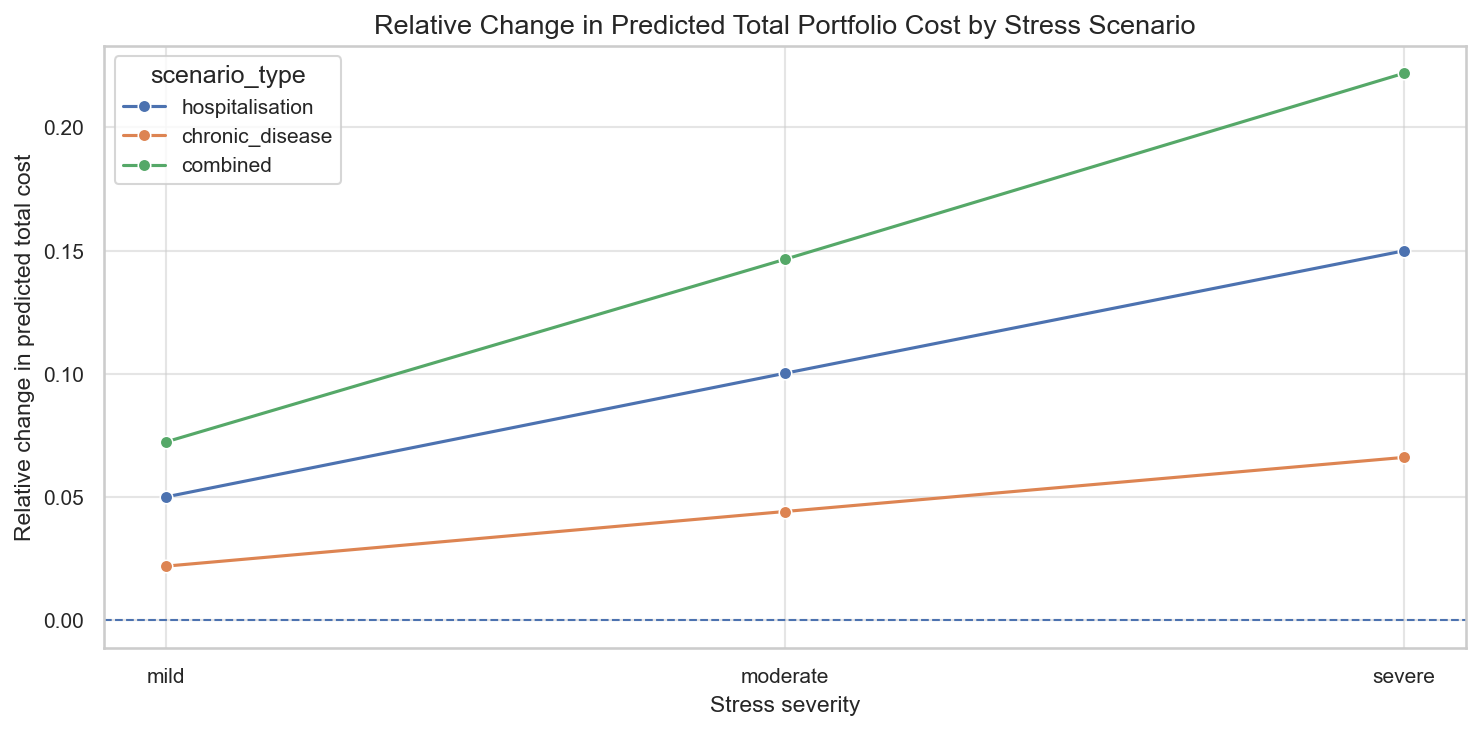

In [15]:
plot_data = scenario_comparison_df[
    scenario_comparison_df["scenario_type"] != "baseline"
    ].copy()

severity_order = ["mild", "moderate", "severe"]

plot_data["severity"] = pd.Categorical(
    plot_data["severity"],
    categories=severity_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.lineplot(
    data=plot_data,
    x="severity",
    y="total_predicted_cost_pct_change",
    hue="scenario_type",
    marker="o",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Relative Change in Predicted Total Portfolio Cost by Stress Scenario")
ax.set_xlabel("Stress severity")
ax.set_ylabel("Relative change in predicted total cost")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_07_total_cost_pct_change_by_scenario",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Figures\fig_07_p95_cost_change_by_scenario.png


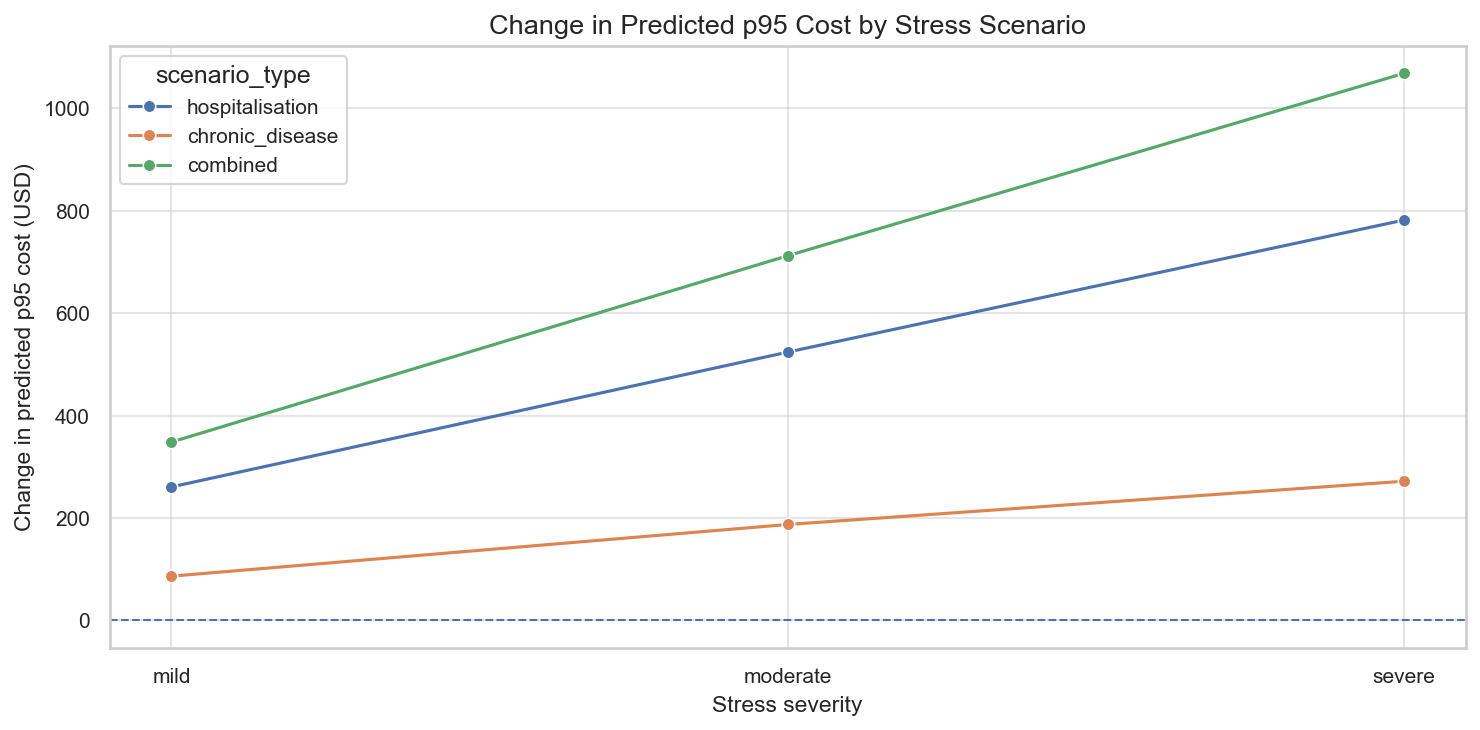

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.lineplot(
    data=plot_data,
    x="severity",
    y="p95_predicted_cost_change",
    hue="scenario_type",
    marker="o",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Change in Predicted p95 Cost by Stress Scenario")
ax.set_xlabel("Stress severity")
ax.set_ylabel("Change in predicted p95 cost (USD)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_07_p95_cost_change_by_scenario",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Figures\fig_07_p95_cost_change_by_scenario.png


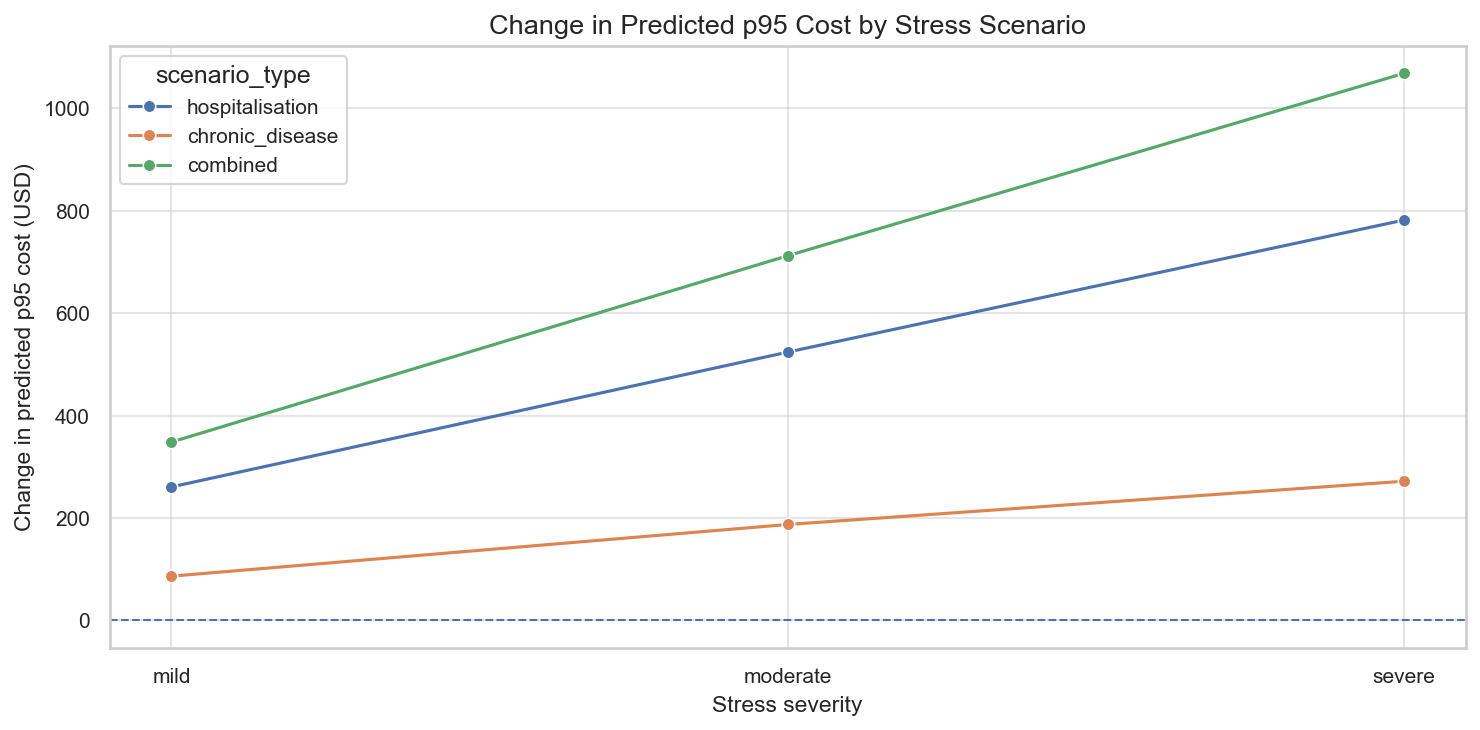

In [17]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.lineplot(
    data=plot_data,
    x="severity",
    y="p95_predicted_cost_change",
    hue="scenario_type",
    marker="o",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Change in Predicted p95 Cost by Stress Scenario")
ax.set_xlabel("Stress severity")
ax.set_ylabel("Change in predicted p95 cost (USD)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_07_p95_cost_change_by_scenario",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Figures\fig_07_tvar_p95_change_by_scenario.png


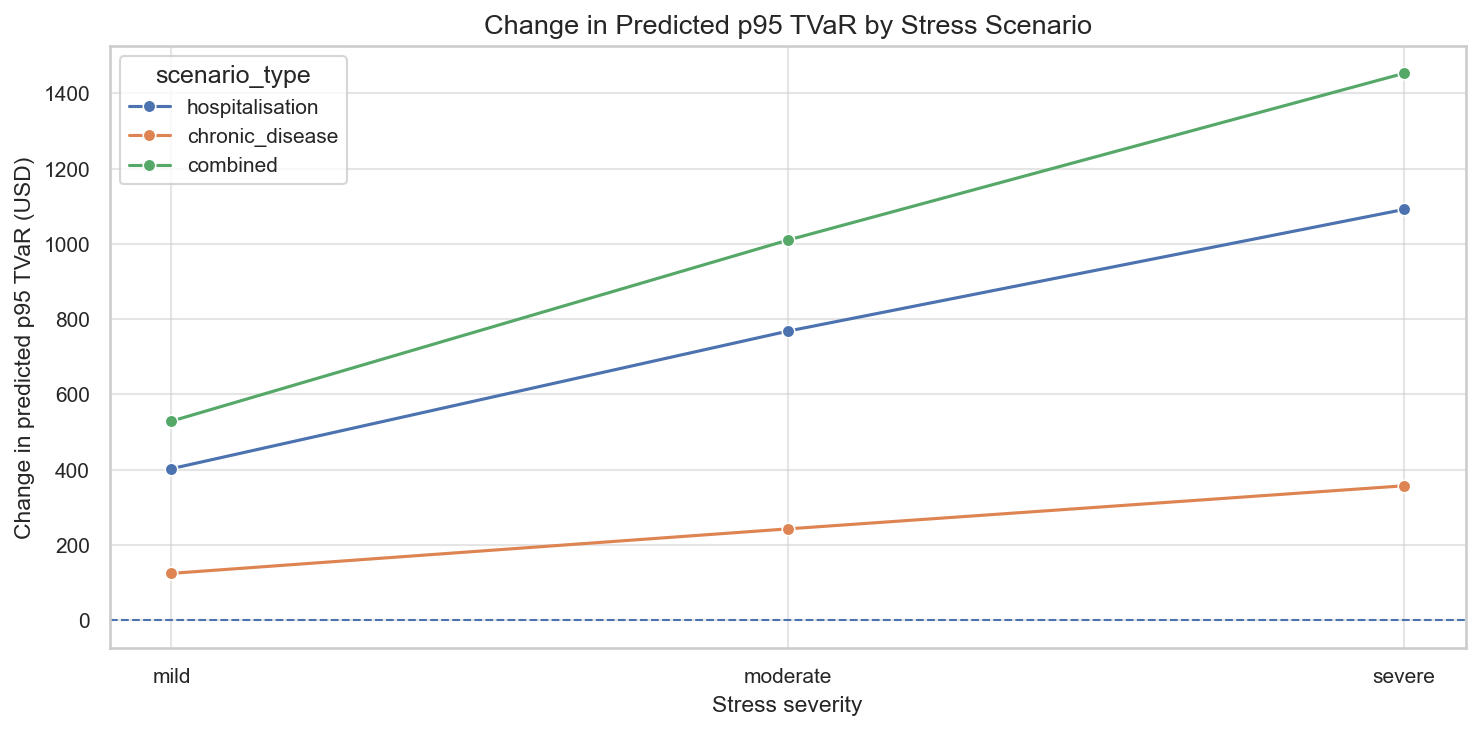

In [18]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.lineplot(
    data=plot_data,
    x="severity",
    y="tvar_p95_change",
    hue="scenario_type",
    marker="o",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Change in Predicted p95 TVaR by Stress Scenario")
ax.set_xlabel("Stress severity")
ax.set_ylabel("Change in predicted p95 TVaR (USD)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_07_tvar_p95_change_by_scenario",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Figures\fig_07_tvar_p99_change_by_scenario.png


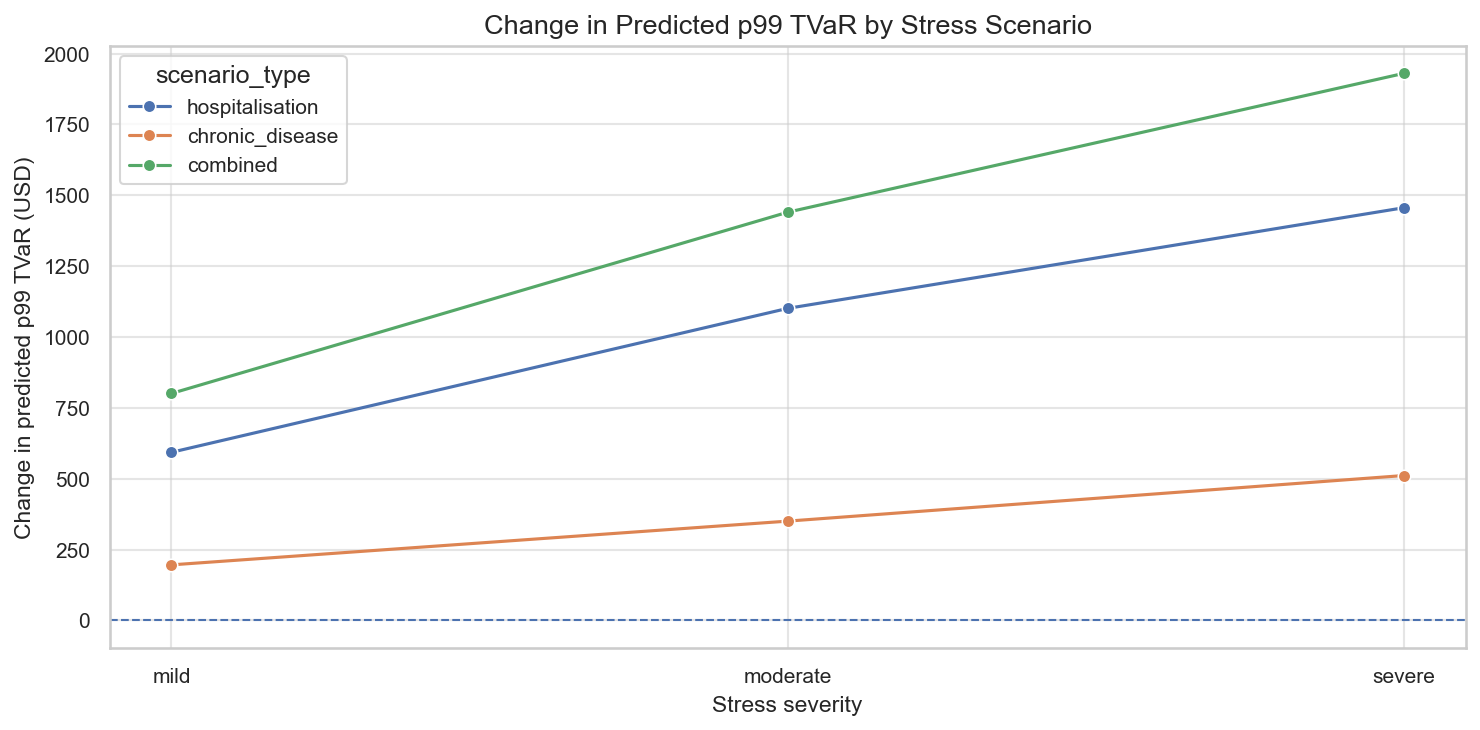

In [19]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.lineplot(
    data=plot_data,
    x="severity",
    y="tvar_p99_change",
    hue="scenario_type",
    marker="o",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Change in Predicted p99 TVaR by Stress Scenario")
ax.set_xlabel("Stress severity")
ax.set_ylabel("Change in predicted p99 TVaR (USD)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_07_tvar_p99_change_by_scenario",
)

plt.show()

In [20]:
def grouped_distribution_table(
        base_df: pd.DataFrame,
        stressed_df: pd.DataFrame,
        column: str,
) -> pd.DataFrame:
    base_counts = (
        base_df[column]
        .astype(str)
        .value_counts(normalize=False)
        .rename("baseline_count")
    )

    stressed_counts = (
        stressed_df[column]
        .astype(str)
        .value_counts(normalize=False)
        .rename("stressed_count")
    )

    base_pct = (
        base_df[column]
        .astype(str)
        .value_counts(normalize=True)
        .rename("baseline_pct")
    )

    stressed_pct = (
        stressed_df[column]
        .astype(str)
        .value_counts(normalize=True)
        .rename("stressed_pct")
    )

    output = pd.DataFrame(index=base_counts.index.union(stressed_counts.index))

    output["baseline_count"] = base_counts.reindex(output.index, fill_value=0).astype(int)
    output["stressed_count"] = stressed_counts.reindex(output.index, fill_value=0).astype(int)
    output["count_change"] = output["stressed_count"] - output["baseline_count"]

    output["baseline_pct"] = base_pct.reindex(output.index, fill_value=0.0)
    output["stressed_pct"] = stressed_pct.reindex(output.index, fill_value=0.0)
    output["pct_point_change"] = output["stressed_pct"] - output["baseline_pct"]

    output = output.reset_index()
    output = output.rename(columns={"index": column})

    return output


combined_severe_df, combined_severe_metadata = apply_combined_stress(
    df,
    stress_fraction=STRESS_LEVELS["severe"],
    random_state=RANDOM_STATE,
)

combined_severe_distribution_tables = {}

distribution_export_metadata = {
    "hospitalizations_grouped": {
        "file_stem": "tab_07_combined_severe_hospitalisation_distribution",
        "label": "tab:07-combined-severe-hospitalisation-distribution",
        "caption": "Distribution of grouped hospitalisation history before and after the severe combined stress scenario.",
    },
    "days_hospitalized_grouped": {
        "file_stem": "tab_07_combined_severe_days_hospitalised_distribution",
        "label": "tab:07-combined-severe-days-hospitalised-distribution",
        "caption": "Distribution of grouped days hospitalised before and after the severe combined stress scenario.",
    },
    "chronic_count_grouped": {
        "file_stem": "tab_07_combined_severe_chronic_distribution",
        "label": "tab:07-combined-severe-chronic-distribution",
        "caption": "Distribution of grouped chronic disease burden before and after the severe combined stress scenario.",
    },
}

for column in [
    "hospitalizations_grouped",
    "days_hospitalized_grouped",
    "chronic_count_grouped",
]:
    print(column)

    distribution_table = grouped_distribution_table(
        df,
        combined_severe_df,
        column,
    )

    combined_severe_distribution_tables[column] = distribution_table

    display(distribution_table)

    export_metadata = distribution_export_metadata[column]

    export_report_table(
        table=distribution_table.round(4),
        table_dir=TABLE_DIR,
        file_stem=export_metadata["file_stem"],
        caption=export_metadata["caption"],
        label=export_metadata["label"],
        index=False,
        float_format="%.4f",
    )

hospitalizations_grouped


,hospitalizations_grouped,baseline_count,stressed_count,count_change,baseline_pct,stressed_pct,pct_point_change
0,0,91031,63708,-27323,0.9103,0.6371,-0.2732
1,1,8582,33344,24762,0.0858,0.3334,0.2476
2,2+,387,2948,2561,0.0039,0.0295,0.0256


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_combined_severe_hospitalisation_distribution.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_combined_severe_hospitalisation_distribution.tex
days_hospitalized_grouped


,days_hospitalized_grouped,baseline_count,stressed_count,count_change,baseline_pct,stressed_pct,pct_point_change
0,0,91031,63708,-27323,0.9103,0.6371,-0.2732
1,1-3,3778,30001,26223,0.0378,0.3000,0.2622
2,4+,5191,6291,1100,0.0519,0.0629,0.0110


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_combined_severe_days_hospitalised_distribution.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_combined_severe_days_hospitalised_distribution.tex
chronic_count_grouped


,chronic_count_grouped,baseline_count,stressed_count,count_change,baseline_pct,stressed_pct,pct_point_change
0,0,46532,32469,-14063,0.4653,0.3247,-0.1406
1,1,37579,40381,2802,0.3758,0.4038,0.0280
2,2,13111,20511,7400,0.1311,0.2051,0.0740
3,3,2452,5595,3143,0.0245,0.0559,0.0314
4,4+,326,1044,718,0.0033,0.0104,0.0072


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_combined_severe_chronic_distribution.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables\tab_07_combined_severe_chronic_distribution.tex
